# GG-PI: Sampling Example for Zundel Cation (H₅O₂⁺)

This notebook demonstrates how to apply GG-PI to sample the Zundel cation at 300K with 32 beads using a pre-trained checkpoint.

**System:**
- Zundel cation: H₅O₂⁺
- Temperature: 300K
- Beads: 32
- Non-periodic (gas phase)

In [1]:
# =============================================================================
# Import Dependencies
# =============================================================================
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle

# GG-PI package imports
from ggpi.nn import ViSNet_Velocity_Network
from ggpi.sampling import ConditionalFlowSampler, GibbsSampler

# Set paths
cwd = Path.cwd()
data_dir = cwd.parent / "data"
checkpoint_dir = cwd.parent / "checkpoints"

# Set random seeds for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# =============================================================================
# Zundel Analysis Helper Functions
# =============================================================================

def zundel_analysis(trajectory_data, num_bins=50, max_range=0.3, oo_max_range=5.1, oo_min_range=4.0):
    """
    Comprehensive analysis of Zundel ion trajectory.
    
    Analyzes proton distribution (delta), O-O distance distribution,
    and atomic fluctuations (radius of gyration).
    
    Args:
        trajectory_data: Shape (B, num_beads, num_atoms, 3)
        num_bins: Number of histogram bins
        max_range: Max range for proton projection analysis
        oo_max_range: Max range for O-O distance analysis
        oo_min_range: Min range for O-O distance analysis
    
    Returns:
        proton_distribution: (num_bins, 2) array [bin_centers, counts]
        oo_distribution: (num_bins, 2) array [bin_centers, counts]
        atom_fluctuations: (B, num_atoms) array of fluctuations
    """
    if trajectory_data.ndim == 3:
        trajectory_data = trajectory_data[:, np.newaxis, :, :]
    B, num_beads, num_atoms, _ = trajectory_data.shape
    
    all_projections = []
    all_oo_distances = []
    
    for b in range(B):
        for bead in range(num_beads):
            coords = trajectory_data[b, bead, :, :]
            
            # Extract O and shared H positions
            o0_pos = coords[0, :]  # O0
            o1_pos = coords[1, :]  # O1
            h_pos = coords[2, :]   # H2 (shared proton)
            
            # Calculate O-O vector and distance
            oo_vector = o1_pos - o0_pos
            oo_distance = np.linalg.norm(oo_vector)
            all_oo_distances.append(oo_distance)
            
            if oo_distance > 1e-8:
                # Calculate proton projection onto O-O axis
                oo_midpoint = (o0_pos + o1_pos) / 2
                h_relative = h_pos - oo_midpoint
                oo_unit = oo_vector / oo_distance
                projection = np.dot(h_relative, oo_unit) / oo_distance
                
                if abs(projection) <= max_range:
                    all_projections.append(projection)
    
    # Create proton distribution histogram
    if len(all_projections) > 0:
        counts, bin_edges = np.histogram(all_projections, bins=num_bins,
                                         range=(-max_range, max_range), density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        proton_distribution = np.column_stack([bin_centers, counts])
    else:
        bin_centers = np.linspace(-max_range, max_range, num_bins)
        proton_distribution = np.column_stack([bin_centers, np.zeros(num_bins)])
    
    # Create O-O distance distribution histogram
    if len(all_oo_distances) > 0:
        counts, bin_edges = np.histogram(all_oo_distances, bins=num_bins,
                                         range=(oo_min_range, oo_max_range), density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        oo_distribution = np.column_stack([bin_centers, counts])
    else:
        bin_centers = np.linspace(oo_min_range, oo_max_range, num_bins)
        oo_distribution = np.column_stack([bin_centers, np.zeros(num_bins)])
    
    # Calculate atomic fluctuations (radius of gyration)
    atom_fluctuations = np.zeros((B, num_atoms))
    for b in range(B):
        for atom_idx in range(num_atoms):
            atom_coords = trajectory_data[b, :, atom_idx, :]
            centroid = np.mean(atom_coords, axis=0)
            distances_sq = np.sum((atom_coords - centroid)**2, axis=1)
            atom_fluctuations[b, atom_idx] = np.sqrt(np.mean(distances_sq))
    
    return proton_distribution, oo_distribution, atom_fluctuations


def extract_delta_roo(trajectory_data, delta_range, oo_range):
    """
    Extract delta and R_OO coordinates from trajectory data.
    
    Args:
        trajectory_data: Shape (B, num_beads, num_atoms, 3) or (B, num_atoms, 3)
        delta_range: Range for delta filtering
        oo_range: Tuple (min, max) for O-O distance filtering
    
    Returns:
        all_deltas, all_roo: Arrays of delta and R_OO values
    """
    if trajectory_data.ndim == 3:
        trajectory_data = trajectory_data[:, np.newaxis, :, :]
    
    B, num_beads, num_atoms, _ = trajectory_data.shape
    all_deltas = []
    all_roo = []
    
    for b in range(B):
        for bead in range(num_beads):
            coords = trajectory_data[b, bead, :, :]
            o0_pos = coords[0, :]
            o1_pos = coords[1, :]
            h_pos = coords[2, :]
            
            oo_vector = o1_pos - o0_pos
            oo_distance = np.linalg.norm(oo_vector)
            
            if oo_distance > 1e-8:
                oo_midpoint = (o0_pos + o1_pos) / 2
                h_relative = h_pos - oo_midpoint
                oo_unit = oo_vector / oo_distance
                delta = np.dot(h_relative, oo_unit)
                
                if abs(delta) <= delta_range and oo_range[0] <= oo_distance <= oo_range[1]:
                    all_deltas.append(delta)
                    all_roo.append(oo_distance)
    
    return np.array(all_deltas), np.array(all_roo)


def compare_zundel_2d(trajectory_list, labels=None, num_bins=50, delta_range=0.3, oo_range=(4.2, 4.9)):
    """
    Compare multiple Zundel trajectories using 2D contour plots.
    
    Args:
        trajectory_list: List of trajectory arrays
        labels: Labels for each trajectory
        num_bins: Number of bins for 2D histogram
        delta_range: Range for delta axis
        oo_range: Tuple (min, max) for R_OO axis
    """
    n_trajectories = len(trajectory_list)
    if labels is None:
        labels = [f'Trajectory {i+1}' for i in range(n_trajectories)]
    
    n_cols = min(3, n_trajectories)
    n_rows = (n_trajectories + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_trajectories == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    axes_flat = axes.flatten() if n_trajectories > 1 else axes
    
    for i, trajectory_data in enumerate(trajectory_list):
        all_deltas, all_roo = extract_delta_roo(trajectory_data, delta_range, oo_range)
        
        if len(all_deltas) == 0:
            print(f"Warning: No valid data for {labels[i]}")
            continue
        
        # Create 2D histogram
        hist_2d, delta_edges, roo_edges = np.histogram2d(
            all_deltas, all_roo, bins=num_bins,
            range=[[-delta_range, delta_range], oo_range], density=True
        )
        delta_centers = (delta_edges[:-1] + delta_edges[1:]) / 2
        roo_centers = (roo_edges[:-1] + roo_edges[1:]) / 2
        X, Y = np.meshgrid(delta_centers, roo_centers)
        
        # Plot contours
        ax = axes_flat[i]
        max_val = np.max(hist_2d.T)
        min_contour = max_val * 0.1
        ax.contour(X, Y, hist_2d.T, levels=np.linspace(min_contour, max_val, 8),
                   colors='black', linewidths=1.2)
        ax.set_xlabel('δ (Bohr)', fontsize=12)
        ax.set_ylabel('R$_{OO}$ (Bohr)', fontsize=12)
        ax.set_title(labels[i], fontsize=12, fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        print(f"\n{labels[i]}: {len(all_deltas)} points, δ: [{all_deltas.min():.3f}, {all_deltas.max():.3f}], R_OO: [{all_roo.min():.3f}, {all_roo.max():.3f}]")
    
    # Hide unused subplots
    for i in range(n_trajectories, len(axes_flat)):
        axes_flat[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

## Load Reference Data

MD data: (50001, 7, 3)
Temperature: 300K, Units: atomic
PIMD data: (4000, 32, 7, 3)


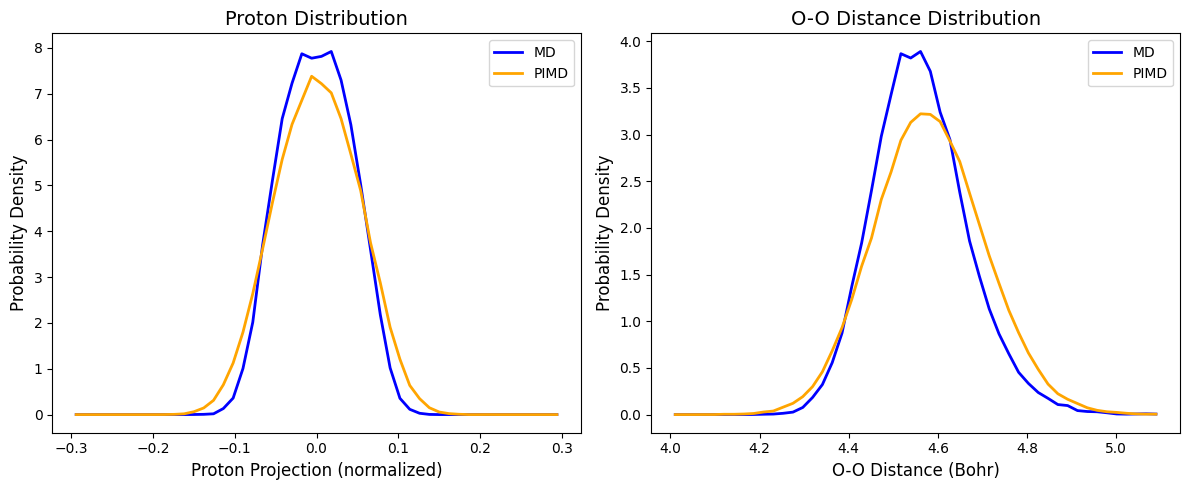


MD: 49815 points, δ: [-0.587, 0.597], R_OO: [4.201, 4.899]

PIMD: 126086 points, δ: [-0.600, 0.600], R_OO: [4.201, 4.900]


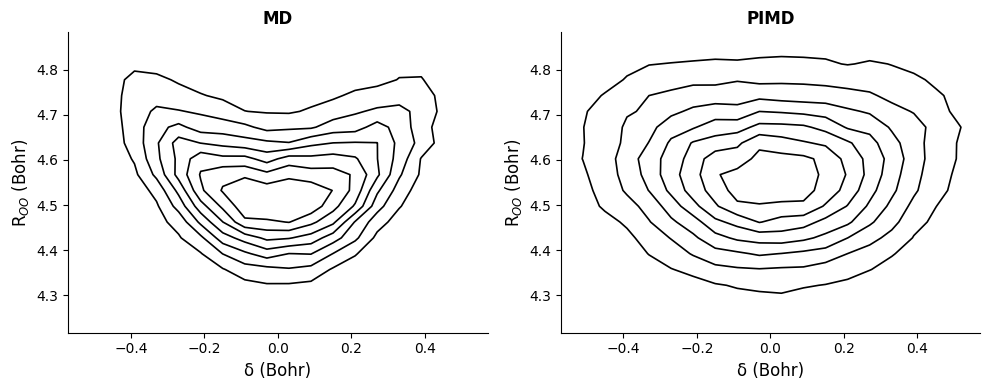

In [3]:
# =============================================================================
# Load MD and PIMD Reference Data
# =============================================================================
# Load MD reference data
data_path = data_dir / "zundel_md_300K.pkl"
with open(data_path, "rb") as f:
    data = pickle.load(f)

pos = np.array(data["x"])
Z = np.array(data["Z"])
prior_sigma = np.array(data['prior_sigma'])

print(f"MD data: {pos.shape}")
print(f"Temperature: {data['T']}K, Units: {data['unit']}")

# Load PIMD reference data
pimd_path = data_dir / "zundel_pimd_300KP32.pkl"
with open(pimd_path, "rb") as f:
    pimd_data = np.array(pickle.load(f)['x'])
print(f"PIMD data: {pimd_data.shape}")

# Calculate reference distributions
proton_md, oo_md, _ = zundel_analysis(pos)
proton_pimd, oo_pimd, _ = zundel_analysis(pimd_data)

# Plot reference comparisons
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(proton_md[:, 0], proton_md[:, 1], 'b-', lw=2, label='MD')
axes[0].plot(proton_pimd[:, 0], proton_pimd[:, 1], 'orange', lw=2, label='PIMD')
axes[0].set_xlabel('Proton Projection (normalized)', fontsize=12)
axes[0].set_ylabel('Probability Density', fontsize=12)
axes[0].set_title('Proton Distribution', fontsize=14)
axes[0].legend()

axes[1].plot(oo_md[:, 0], oo_md[:, 1], 'b-', lw=2, label='MD')
axes[1].plot(oo_pimd[:, 0], oo_pimd[:, 1], 'orange', lw=2, label='PIMD')
axes[1].set_xlabel('O-O Distance (Bohr)', fontsize=12)
axes[1].set_ylabel('Probability Density', fontsize=12)
axes[1].set_title('O-O Distance Distribution', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

# Plot 2D comparison
num_bins = 20
delta_range = 0.6
oo_range = (4.2, 4.9)

compare_zundel_2d([pos, pimd_data], labels=['MD', 'PIMD'],
                  num_bins=num_bins, delta_range=delta_range, oo_range=oo_range)

## Load Pre-trained Model

In [4]:
# =============================================================================
# Load Pre-trained Model and Setup Sampler
# =============================================================================
checkpoint_path = checkpoint_dir / "zundel.pt"

model = ViSNet_Velocity_Network.load_model(checkpoint_path, device=device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params:,}")

# Note: torch.compile may cause issues with small molecules
# Uncomment if needed: model = torch.compile(model)


# Setup flow sampler (no box_size for gas phase)
sampler = ConditionalFlowSampler(
    model,
    Z=torch.as_tensor(Z, dtype=torch.int64, device=device),
    prior_sigma=torch.as_tensor(prior_sigma, dtype=torch.float32, device=device),
    device=device,
    sample_method='heun',
    fix_graph=True,
    num_steps=5,
    max_batch_size=40_000,
    return_cpu=False
)

# Setup Gibbs sampler
gibbs = GibbsSampler(
    sampler,
    device=device,
    cache_update_interval=10
)

Model parameters: 35,016
ConditionalFlowSampler initialized: method=heun, steps=5, fix_graph=True
GibbsSampler initialized on cuda, cutoff=10.0, cache_interval=10, cache_threshold=2.0, use_cache=False


## Run GG-PI Sampling

In [ ]:
# =============================================================================
# Run Gibbs Sampling
# =============================================================================
import time

torch.cuda.empty_cache()

# Select random initial configurations from MD data as initial points for each chain
num_initial = 5000
max_iterations = 100
random_indices = np.random.choice(pos.shape[0], num_initial, replace=False)
initial_configs = pos[random_indices]
initial_configs = torch.as_tensor(initial_configs, dtype=torch.float32, device=device)

print(f"Initial configurations: {initial_configs.shape}")

# Run Gibbs sampling
start = time.time()
output, history = gibbs.sample(
    initial_configs,
    num_beads=32,
    max_iterations=max_iterations,
    record_freq=10
)
print(f"Gibbs sampling completed in {time.time() - start:.2f} seconds")

Initial configurations: torch.Size([3000, 7, 3])
Initial Rg: 3.1123890221812153e-14, num_beads: 32
Step: 10/100, Rg: 0.05751781165599823
Step: 20/100, Rg: 0.06653442233800888
Step: 30/100, Rg: 0.07006188482046127
Step: 40/100, Rg: 0.07142709195613861
Step: 50/100, Rg: 0.07227589190006256
Step: 60/100, Rg: 0.07240770012140274
Step: 70/100, Rg: 0.0724877342581749
Step: 80/100, Rg: 0.07252611219882965
Step: 90/100, Rg: 0.07269622385501862
Step: 100/100, Rg: 0.07276855409145355
Gibbs sampling completed in 120.99 seconds


## Compare Results

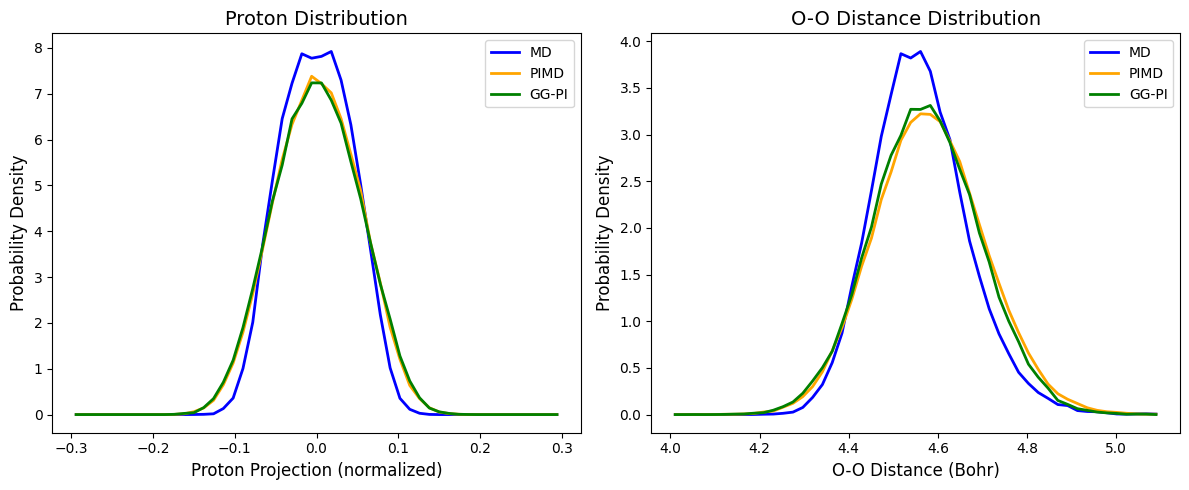


MD: 49815 points, δ: [-0.587, 0.597], R_OO: [4.201, 4.899]

PIMD: 126086 points, δ: [-0.600, 0.600], R_OO: [4.201, 4.900]

GG-PI: 94859 points, δ: [-0.600, 0.600], R_OO: [4.200, 4.900]


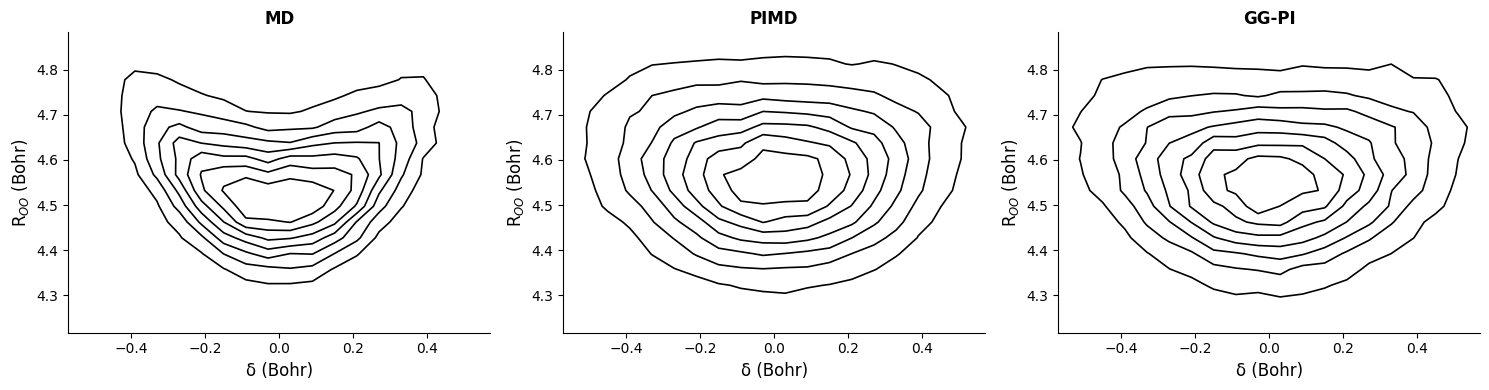

In [6]:
# =============================================================================
# Compare Results
# =============================================================================
# Calculate distributions for GG-PI samples
proton_ggpi, oo_ggpi, _ = zundel_analysis(output)

# Plot 1D comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(proton_md[:, 0], proton_md[:, 1], 'b-', lw=2, label='MD')
axes[0].plot(proton_pimd[:, 0], proton_pimd[:, 1], 'orange', lw=2, label='PIMD')
axes[0].plot(proton_ggpi[:, 0], proton_ggpi[:, 1], 'g-', lw=2, label='GG-PI')
axes[0].set_xlabel('Proton Projection (normalized)', fontsize=12)
axes[0].set_ylabel('Probability Density', fontsize=12)
axes[0].set_title('Proton Distribution', fontsize=14)
axes[0].legend()

axes[1].plot(oo_md[:, 0], oo_md[:, 1], 'b-', lw=2, label='MD')
axes[1].plot(oo_pimd[:, 0], oo_pimd[:, 1], 'orange', lw=2, label='PIMD')
axes[1].plot(oo_ggpi[:, 0], oo_ggpi[:, 1], 'g-', lw=2, label='GG-PI')
axes[1].set_xlabel('O-O Distance (Bohr)', fontsize=12)
axes[1].set_ylabel('Probability Density', fontsize=12)
axes[1].set_title('O-O Distance Distribution', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

# Plot 2D comparison
compare_zundel_2d([pos, pimd_data, output], labels=['MD', 'PIMD', 'GG-PI'],
                  num_bins=num_bins, delta_range=delta_range, oo_range=oo_range)